In [1]:
import requests
import os
from io import StringIO
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
headers = {"User-Agent": "Mozilla/5.0"}
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

response = requests.get(url, headers=headers)
tables = pd.read_html(StringIO(response.text))
sp500 = tables[0]
tickers = sp500["Symbol"].tolist()
tickers = [t.replace(".", "-") for t in tickers]

print(f"found {len(tickers)} tickers")
print(tickers[:5])

found 503 tickers
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN']


In [3]:
if os.path.exists("data/prices_raw.parquet"):
    prices = pd.read_parquet("data/prices_raw.parquet")
    print(f"loaded from disk: {prices.shape}")
else:
    raw = yf.download(tickers, start="2015-01-01", end="2025-12-31", auto_adjust=True)
    prices = raw["Close"]
    os.makedirs("data", exist_ok=True)
    prices.to_parquet("data/prices_raw.parquet")
    print(f"downloaded and saved: {prices.shape}")

[*********************100%***********************]  503 of 503 completed


downloaded and saved: (2765, 503)


In [4]:
# drop columns with more than 20% missing
min_count = int(0.8 * len(prices))
prices_clean = prices.dropna(axis=1, thresh=min_count)

# forward fill small gaps
prices_clean = prices_clean.ffill()

# drop any remaining NaNs
prices_clean = prices_clean.dropna(axis=1)

print(f"tickers before: {prices.shape[1]}")
print(f"tickers after:  {prices_clean.shape[1]}")
print(f"any NaNs left:  {prices_clean.isnull().any().any()}")

tickers before: 503
tickers after:  462
any NaNs left:  False


In [5]:
log_returns = np.log(prices_clean / prices_clean.shift(1))
log_returns = log_returns.dropna(how="all")

print(log_returns.shape)
print(log_returns.head())

(2764, 462)
Ticker             A      AAPL      ABBV       ABT      ACGL       ACN  \
Date                                                                     
2015-01-05 -0.018916 -0.028576 -0.018999  0.000222 -0.006002 -0.017029   
2015-01-06 -0.015701  0.000094 -0.004962 -0.011421  0.002233 -0.007239   
2015-01-07  0.013185  0.013925  0.039621  0.008075  0.005818  0.020772   
2015-01-08  0.029534  0.037703  0.010405  0.020346  0.017254  0.015134   
2015-01-09 -0.007364  0.001072 -0.027736 -0.010564 -0.008759 -0.001113   

Ticker          ADBE       ADI       ADM       ADP  ...       WTW        WY  \
Date                                                ...                       
2015-01-05 -0.004989 -0.018353 -0.035215 -0.000721  ... -0.007209  0.000000   
2015-01-06 -0.020350 -0.023753 -0.019910 -0.008325  ... -0.004986 -0.001109   
2015-01-07  0.008190  0.010462  0.014920  0.008685  ...  0.014213  0.003045   
2015-01-08  0.025135  0.017501 -0.014716  0.022681  ...  0.011360  0.01072

In [6]:
log_returns.to_csv("data/log_returns.csv")
print("saved")

saved


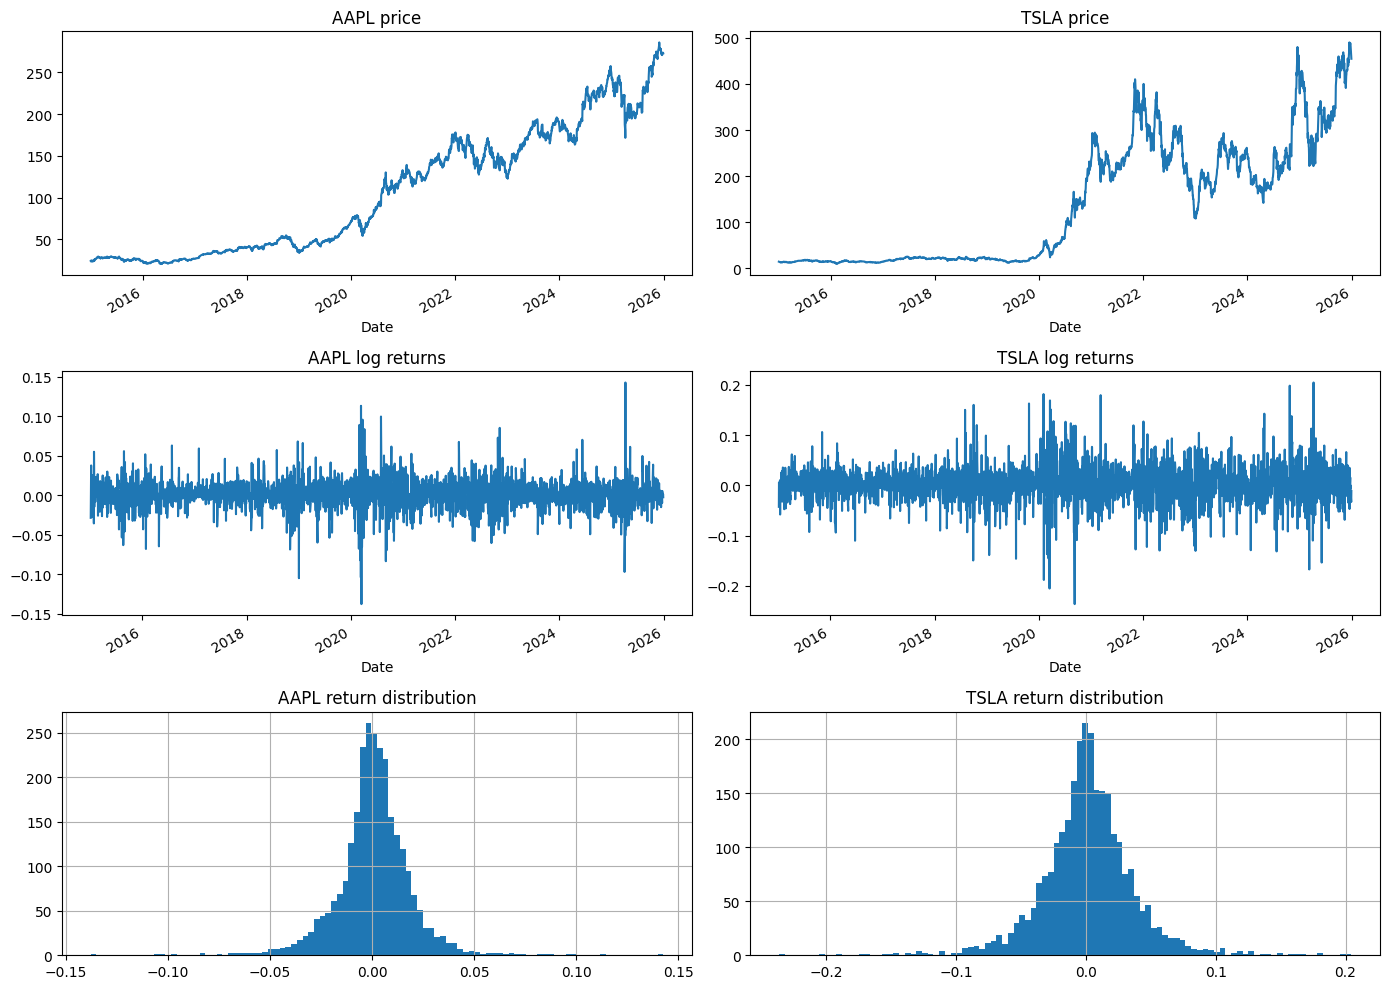

In [8]:
stocks = ["AAPL", "TSLA"]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, ticker in enumerate(stocks):
    prices_clean[ticker].plot(ax=axes[0, i], title=f"{ticker} price")
    log_returns[ticker].plot(ax=axes[1, i], title=f"{ticker} log returns")
    log_returns[ticker].hist(ax=axes[2, i], bins=100)
    axes[2, i].set_title(f"{ticker} return distribution")

plt.tight_layout()
plt.show()